# <font color="#2E86C1"><b>AICE Associate 4회 모의고사</b></font>
---
##  <font color="#117A65"><b>차량 연비 예측</b></font>
### <font color="#5D6D7E"><b>목적</b></font>  
<b>차량의 제원 및 주행 성능 정보를 바탕으로 연비(`mpg`)를 예측</b>하여  
고연비 차량 개발, 고객 맞춤형 추천 서비스 등에 활용할 수 있도록  
예측 모델을 구축합니다.

### <font color="#5D6D7E"><b>배경 시나리오</b></font>

자동차 제조사 <b>B사</b>는 연비 효율에 대한 소비자들의 관심이 높아짐에 따라  
각 차량의 스펙(엔진, 무게, 가속도 등)과 실제 연비(`mpg`) 간의 관계를 분석하고,  
연비 예측 모델을 개발하고자 합니다.  

회사는 다양한 차종의 연비와 차량 제원 데이터를 수집하였으며,  
다음 정보를 기반으로 <b>연비(`mpg`)</b>를 예측하는 회귀 모델을 구축하려고 합니다.

---

### 📊 <font color="#5D6D7E"><b>데이터 설명</b></font>  
<b>파일 이름: `auto_mpg.xlsx`</b>

| 컬럼명           | 설명                                                              |
|------------------|-------------------------------------------------------------------|
| `mpg`            | <mark><b>연비 (Miles Per Gallon)</b></mark> ← <b>예측 대상</b>     |
| `cylinders`      | 실린더 수                                                         |
| `displacement`   | 배기량 (단위: cubic inches)                                       |
| `horsepower`     | 마력                                                              |
| `weight`         | 차량 무게 (단위: lbs)                                             |
| `acceleration`   | 가속 성능 (0→60mph까지 걸리는 시간, 초 단위)                     |
| `model_year`     | 차량 출시 연도 (예: 70 = 1970)                                     |
| `origin`         | 제조 국가 코드 (1: 미국, 2: 유럽, 3: 일본)                        |
| `name`           | 차량 이름 (예: "chevrolet chevelle malibu")                      |

---


### 문제 1. 라이브러리 불러오기

🎯 목표  
데이터 분석을 위해 pandas, numpy, seaborn, matplotlib 라이브러리를 불러옵니다.

📑 조건  
- pandas를 `pd`, numpy를 `np`, seaborn을 `sns`, matplotlib.pyplot을 `plt`로 임포트하세요.



In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### 문제 2. 데이터 파일 불러오기

🎯 목표  
auto_mpg.xlsx 파일을 불러와 mpg_df 데이터프레임을 생성합니다.

📑 조건
- pandas를 이용하여 파일을 읽고 `mpg_df`에 저장하세요.



In [7]:
mpg_df = pd.read_excel('C:/juehyeon/aice_test/materials/datasets/auto_mpg.xlsx')

In [8]:
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1,chevrolet chevelle malibu
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1,buick skylark 320
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1,plymouth satellite
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1,amc rebel sst
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1,ford torino


## [문제 3] 컬럼명 변경

🎯 목표
- 영어로 되어져 있는 컬럼명을 한글로 수정하고자 합니다.

📑 컬럼명 변경 조건
  - mpg	연비
  - cylinders = 실린더 수
  - displacement = 배기량
  - horsepower = 마력
  - weight = 차량 무게
  - acceleration = 가속 성능 
  - model_year = 차량 출시 연도
  - origin = 제조 국가 코드
  - name = 차량 이름

📑 조건
- inplace = True

In [12]:
mpg_df = mpg_df.rename(columns = {
    'mpg' : '연비', 
    'cylinders' : '실린더수',
    'displacement' : '배기량',
    'horsepower' : '마력', 
    'weight' : '차량 무게',
    'acceleration' : '가속 성능',
    'model_year' : '차량 출시 연도', 
    'origin' : '제조 국가 코드', 
    'name' : '차량 이름'
})

In [13]:
mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   연비        481 non-null    float64
 1   실린더수      496 non-null    float64
 2   배기량       492 non-null    float64
 3   마력        491 non-null    float64
 4   차량 무게     490 non-null    float64
 5   가속 성능     492 non-null    float64
 6   차량 출시 연도  496 non-null    float64
 7   제조 국가 코드  498 non-null    int64  
 8   차량 이름     498 non-null    object 
dtypes: float64(7), int64(1), object(1)
memory usage: 35.1+ KB


## [문제 4] 결측치 확인 및 처리

🎯 목표
- 전체 컬럼에 대한 결측치를 확인하는 코드를 이용하여, 결측치를 처리하세요.

📑 조건
- 결측치가 존재하는 해당 행 삭제
- 처리한 데이터는 del_df 변수에 저장

In [31]:
initial_columns = mpg_df.shape[0]
del_columns = mpg_df.isna().sum()
initial_columns
# del_columns

498

In [32]:
del_df = mpg_df.copy()

In [33]:
del_df = del_df.dropna()

In [34]:
del_df.shape[0]

455

In [38]:
import matplotlib.font_manager as fm
import platform

# 운영체제별 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')  # 리눅스: 나눔고딕 설치 필요

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## [문제 5] 이상치 제거

🎯 목표  
마력과 연비에 대한 그래프를 확인하고 이상치를 제거하고자 합니다.

[사전 실행 지시사항]
- 아래 셀을 실행하여 scatterplot을 확인하세요.


<Axes: xlabel='마력', ylabel='연비'>

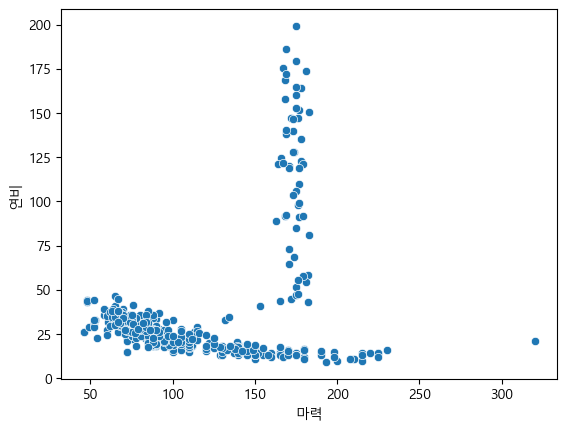

In [39]:
sns.scatterplot(data=del_df, x='마력', y='연비')

📑 조건  
위의 그래프를 보면 이상치가 존재한다는 것을 확인할 수 있습니다.

- 마력이 150이상이면서 연비가 50 초과하는 이상치를 제거하세요.
- inplace= True

In [ ]:
del_df = deld_